#Section 1 - Environment Setup

In [ ]:
import torch

print("PyTorch Version:", torch.__version__)
print("GPU Available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU Name:", torch.cuda.get_device_name(0))

PyTorch Version: 2.11.0+cu128
GPU Available: True
GPU Name: Tesla T4


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

project_dir = "/content/drive/MyDrive/RemoteSensing_Internship"

os.makedirs(project_dir, exist_ok=True)

print("Project directory created:", project_dir)

Project directory created: /content/drive/MyDrive/RemoteSensing_Internship


In [ ]:
%cd /content/drive/MyDrive/RemoteSensing_Internship

/content/drive/MyDrive/RemoteSensing_Internship


In [ ]:
import os

print("Current Working Directory:")
print(os.getcwd())

Current Working Directory:
/content/drive/MyDrive/RemoteSensing_Internship


In [ ]:
!pip install timm


In [ ]:
import timm

models = timm.list_models()
print("Total models:", len(models))

Total models: 1288


In [ ]:
[x for x in models if "fract" in x.lower()]


[]

In [ ]:
[x for x in models if "mamba" in x.lower()]

['mambaout_base',
 'mambaout_base_plus_rw',
 'mambaout_base_short_rw',
 'mambaout_base_tall_rw',
 'mambaout_base_wide_rw',
 'mambaout_femto',
 'mambaout_kobe',
 'mambaout_small',
 'mambaout_small_rw',
 'mambaout_tiny',
 'test_mambaout']

## Summary

- GPU Enabled: Tesla T4
- Google Drive Mounted
- Project Directory Created
- TIMM Installed Successfully
- FractalNet is NOT available in TIMM
- MambaOut models ARE available in TIMM

Conclusion:
Mamba can be imported directly using TIMM.
FractalNet will require a separate PyTorch implementation.

# Section 2 - Dataset Preparation (EuroSAT)

In [ ]:
import torch
import torchvision

from torchvision import datasets
from torchvision import transforms
from torch.utils.data import DataLoader
from torch.utils.data import random_split

import matplotlib.pyplot as plt
import numpy as np
import os

In [ ]:
import os

dataset_dir = "/content/drive/MyDrive/RemoteSensing_Internship/Datasets"

os.makedirs(dataset_dir, exist_ok=True)

print(dataset_dir)

/content/drive/MyDrive/RemoteSensing_Internship/Datasets


In [ ]:
!pip install -q kagglehub

In [ ]:
import kagglehub

# Download the EuroSAT RGB dataset
path = kagglehub.dataset_download("apollo2506/eurosat-dataset")

print("Dataset downloaded to:", path)

Using Colab cache for faster access to the 'eurosat-dataset' dataset.
Dataset downloaded to: /kaggle/input/eurosat-dataset


In [ ]:
import os

print(path)

/kaggle/input/eurosat-dataset


In [ ]:
import os

for root, dirs, files in os.walk(path):
    print(root)
    print("Folders:", dirs[:10])
    print("Files:", files[:5])
    print("-"*60)

/kaggle/input/eurosat-dataset
Folders: ['EuroSATallBands', 'EuroSAT']
Files: []
------------------------------------------------------------
/kaggle/input/eurosat-dataset/EuroSATallBands
Folders: ['SeaLake', 'Highway', 'River', 'Pasture', 'Industrial', 'Residential', 'PermanentCrop', 'AnnualCrop', 'Forest', 'HerbaceousVegetation']
Files: ['validation.csv', 'train.csv', 'test.csv', 'label_map.json']
------------------------------------------------------------
/kaggle/input/eurosat-dataset/EuroSATallBands/SeaLake
Folders: []
Files: ['SeaLake_2893.tif', 'Jakarta_000334.tif', 'SeaLake_2765.tif', 'SeaLake_2733.tif', 'SeaLake_1037.tif']
------------------------------------------------------------
/kaggle/input/eurosat-dataset/EuroSATallBands/Highway
Folders: []
Files: ['Highway_1963.tif', 'Highway_51.tif', 'Highway_102.tif', 'Highway_1603.tif', 'Highway_1224.tif']
------------------------------------------------------------
/kaggle/input/eurosat-dataset/EuroSATallBands/River
Folders: []
File

In [ ]:
dataset_path = path + "/EuroSAT"

print(dataset_path)

/kaggle/input/eurosat-dataset/EuroSAT


In [ ]:
from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


In [ ]:
from torchvision.datasets import ImageFolder

dataset = ImageFolder(
    root=dataset_path,
    transform=transform
)

In [ ]:
print("Total Images:", len(dataset))

print("\nNumber of Classes:", len(dataset.classes))

print("\nClasses:")

for i, class_name in enumerate(dataset.classes):
    print(f"{i}: {class_name}")

Total Images: 27000

Number of Classes: 10

Classes:
0: AnnualCrop
1: Forest
2: HerbaceousVegetation
3: Highway
4: Industrial
5: Pasture
6: PermanentCrop
7: Residential
8: River
9: SeaLake


In [ ]:
image, label = dataset[0]

print("Image Shape:", image.shape)
print("Label Index:", label)
print("Class:", dataset.classes[label])

Image Shape: torch.Size([3, 224, 224])
Label Index: 0
Class: AnnualCrop


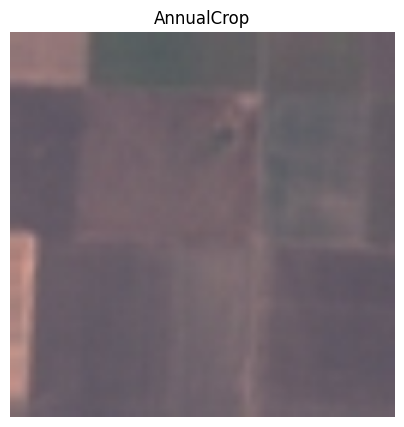

In [ ]:
import matplotlib.pyplot as plt
import torch

# Reverse normalization for visualization
img = image.permute(1, 2, 0)

mean = torch.tensor([0.485, 0.456, 0.406])
std = torch.tensor([0.229, 0.224, 0.225])

img = img * std + mean
img = img.clamp(0, 1)

plt.figure(figsize=(5,5))
plt.imshow(img)
plt.title(dataset.classes[label])
plt.axis("off")
plt.show()

#Section 3 - Data Preparation

EuroSAT Dataset

Train / Validation / Test Split

Create DataLoaders

Verify Batches

Ready for FractalNet & Mamba

In [ ]:
print("Total Images:", len(dataset))

Total Images: 27000


In [ ]:
from torch.utils.data import random_split

# Dataset size
dataset_size = len(dataset)

# Split ratios
train_size = int(0.8 * dataset_size)
val_size = int(0.1 * dataset_size)
test_size = dataset_size - train_size - val_size

print("Train:", train_size)
print("Validation:", val_size)
print("Test:", test_size)

Train: 21600
Validation: 2700
Test: 2700


In [ ]:
train_dataset, val_dataset, test_dataset = random_split(
    dataset,
    [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

In [ ]:
print("Training Images:", len(train_dataset))
print("Validation Images:", len(val_dataset))
print("Testing Images:", len(test_dataset))

Training Images: 21600
Validation Images: 2700
Testing Images: 2700


In [ ]:
from torch.utils.data import DataLoader

BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2
)

In [ ]:
images, labels = next(iter(train_loader))

print("Image Batch Shape:", images.shape)
print("Label Batch Shape:", labels.shape)

Image Batch Shape: torch.Size([32, 3, 224, 224])
Label Batch Shape: torch.Size([32])


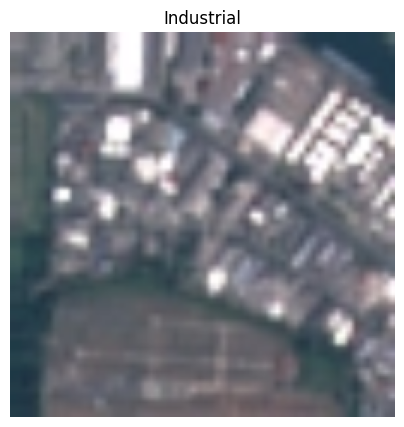

In [ ]:
import matplotlib.pyplot as plt

# Take first image from the batch
img = images[0].permute(1, 2, 0)

# Reverse normalization
mean = torch.tensor([0.485, 0.456, 0.406])
std = torch.tensor([0.229, 0.224, 0.225])

img = img * std + mean
img = img.clamp(0, 1)

plt.figure(figsize=(5,5))
plt.imshow(img)
plt.title(dataset.classes[labels[0].item()])
plt.axis("off")
plt.show()

## Phase 3 Summary

- Loaded the EuroSAT RGB dataset using ImageFolder.
- Applied resizing and normalization transforms.
- Split the dataset into:
  - 80% Training
  - 10% Validation
  - 10% Testing
- Created DataLoaders with a batch size of 32.
- Verified that the batches contain images of shape (32, 3, 224, 224), making the data ready for model training.

# Section 4 - MambaOut Model

In [ ]:
import timm

model = timm.create_model(
    "mambaout_tiny",
    pretrained=False,
    num_classes=10
)

print(model)

MambaOut(
  (stem): Stem(
    (conv1): Conv2d(3, 48, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (norm1): LayerNorm((48,), eps=1e-06, elementwise_affine=True)
    (act): GELU(approximate='none')
    (conv2): Conv2d(48, 96, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (norm2): LayerNorm((96,), eps=1e-06, elementwise_affine=True)
  )
  (stages): Sequential(
    (0): MambaOutStage(
      (downsample): Identity()
      (blocks): Sequential(
        (0): GatedConvBlock(
          (norm): LayerNorm((96,), eps=1e-06, elementwise_affine=True)
          (fc1): Linear(in_features=96, out_features=512, bias=True)
          (act): GELU(approximate='none')
          (conv): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
          (fc2): Linear(in_features=256, out_features=96, bias=True)
          (ls): Identity()
          (drop_path): Identity()
        )
        (1): GatedConvBlock(
          (norm): LayerNorm((96,), eps=1e-06, elementwise_affin

In [ ]:
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total Parameters: {total_params:,}")
print(f"Trainable Parameters: {trainable_params:,}")

Total Parameters: 24,263,146
Trainable Parameters: 24,263,146


# Section 5 - Training Setup

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = model.to(device)

print(device)

cuda


In [ ]:
import torch.nn as nn

criterion = nn.CrossEntropyLoss()

print(criterion)

CrossEntropyLoss()


In [ ]:
import torch.optim as optim

optimizer = optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

print(optimizer)

AdamW (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: True
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0001
    maximize: False
    weight_decay: 0.0001
)


In [ ]:
scheduler = optim.lr_scheduler.StepLR(
    optimizer,
    step_size=5,
    gamma=0.1
)

print(scheduler)

# Section 6 - Model Training

In [ ]:
def train_one_epoch(model, loader, criterion, optimizer, device):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = outputs.max(1)

        total += labels.size(0)

        correct += predicted.eq(labels).sum().item()

    epoch_loss = running_loss / len(loader)
    epoch_accuracy = 100 * correct / total

    return epoch_loss, epoch_accuracy

In [ ]:
def evaluate(model, loader, criterion, device):

    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_loss += loss.item()

            _, predicted = outputs.max(1)

            total += labels.size(0)

            correct += predicted.eq(labels).sum().item()

    epoch_loss = running_loss / len(loader)
    epoch_accuracy = 100 * correct / total

    return epoch_loss, epoch_accuracy

In [ ]:
EPOCHS = 5

train_losses = []
train_accuracies = []

val_losses = []
val_accuracies = []

In [ ]:
best_accuracy = 0
import time

start_time = time.time()

for epoch in range(EPOCHS):

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    val_loss, val_acc = evaluate(
        model,
        val_loader,
        criterion,
        device
    )

    scheduler.step()

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)

    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    print(f"Epoch {epoch+1}/{EPOCHS}")

    print(f"Train Loss : {train_loss:.4f}")
    print(f"Train Accuracy : {train_acc:.2f}%")

    print(f"Validation Loss : {val_loss:.4f}")
    print(f"Validation Accuracy : {val_acc:.2f}%")

    print("-"*40)

    if val_acc > best_accuracy:

        best_accuracy = val_acc

        torch.save(
            model.state_dict(),
            "best_mamba_eurosat.pth"
        )
end_time = time.time()

training_time = end_time - start_time

print(f"Training Time: {training_time:.2f} seconds")

print("Training Finished!")
print("Best Validation Accuracy:", best_accuracy)

Epoch 1/5
Train Loss : 1.2023
Train Accuracy : 57.43%
Validation Loss : 0.7399
Validation Accuracy : 72.96%
----------------------------------------
Epoch 2/5
Train Loss : 0.5832
Train Accuracy : 79.34%
Validation Loss : 0.5054
Validation Accuracy : 82.26%
----------------------------------------
Epoch 3/5
Train Loss : 0.3781
Train Accuracy : 86.40%
Validation Loss : 0.3305
Validation Accuracy : 88.48%
----------------------------------------
Epoch 4/5
Train Loss : 0.2656
Train Accuracy : 90.45%
Validation Loss : 0.3155
Validation Accuracy : 89.56%
----------------------------------------
Epoch 5/5
Train Loss : 0.2118
Train Accuracy : 92.51%
Validation Loss : 0.2782
Validation Accuracy : 91.26%
----------------------------------------
Training Time: 2301.12 seconds
Training Finished!
Best Validation Accuracy: 91.25925925925925


#Section 7 - Model Evaluation

In [ ]:
model.load_state_dict(torch.load("best_mamba_eurosat.pth"))

model.eval()

print("Best model loaded successfully!")

Best model loaded successfully!


In [ ]:
test_loss, test_accuracy = evaluate(
    model,
    test_loader,
    criterion,
    device
)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.2f}%")

Test Loss: 0.2518
Test Accuracy: 91.04%


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import torch.nn.functional as F

all_preds = []
all_labels = []
all_probs = []

model.eval()

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        probs = F.softmax(outputs, dim=1)

        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

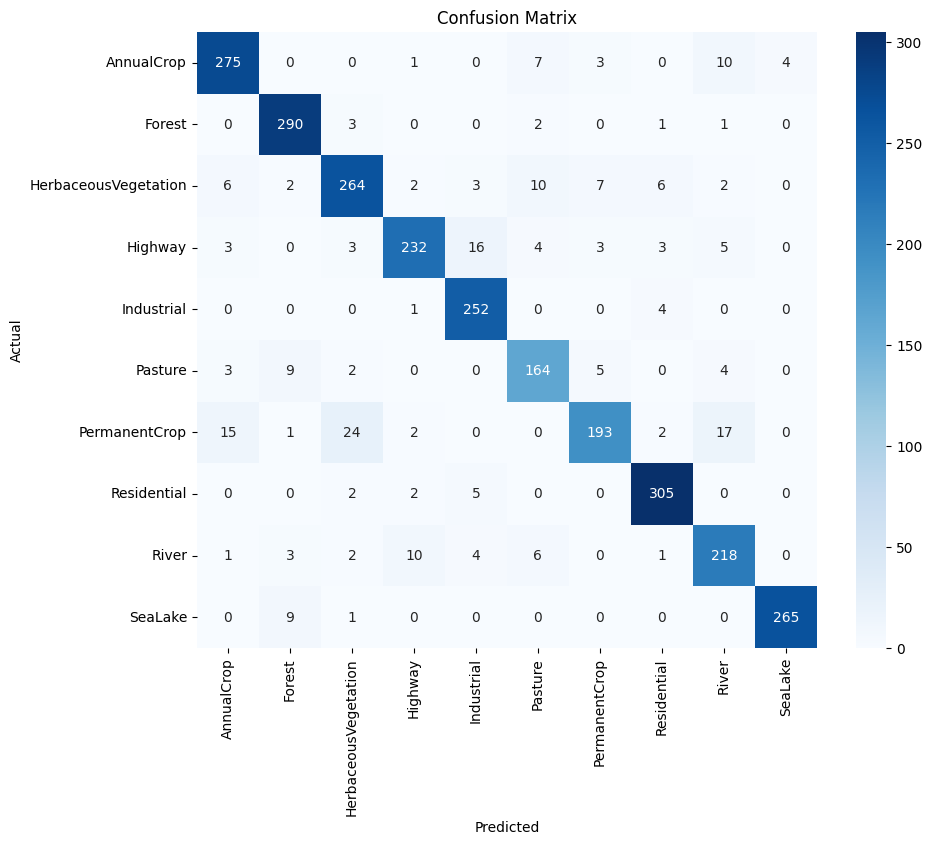

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap="Blues",
    xticklabels=dataset.classes,
    yticklabels=dataset.classes
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(
    all_labels,
    all_preds,
    target_names=dataset.classes
))

                      precision    recall  f1-score   support

          AnnualCrop       0.91      0.92      0.91       300
              Forest       0.92      0.98      0.95       297
HerbaceousVegetation       0.88      0.87      0.88       302
             Highway       0.93      0.86      0.89       269
          Industrial       0.90      0.98      0.94       257
             Pasture       0.85      0.88      0.86       187
       PermanentCrop       0.91      0.76      0.83       254
         Residential       0.95      0.97      0.96       314
               River       0.85      0.89      0.87       245
             SeaLake       0.99      0.96      0.97       275

            accuracy                           0.91      2700
           macro avg       0.91      0.91      0.91      2700
        weighted avg       0.91      0.91      0.91      2700



In [ ]:
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score

precision = precision_score(all_labels, all_preds, average='weighted')
recall = recall_score(all_labels, all_preds, average='weighted')
f1 = f1_score(all_labels, all_preds, average='weighted')

auc = roc_auc_score(
    all_labels,
    all_probs,
    multi_class='ovr',
    average='weighted'
)

#Section 8 - Training Curves

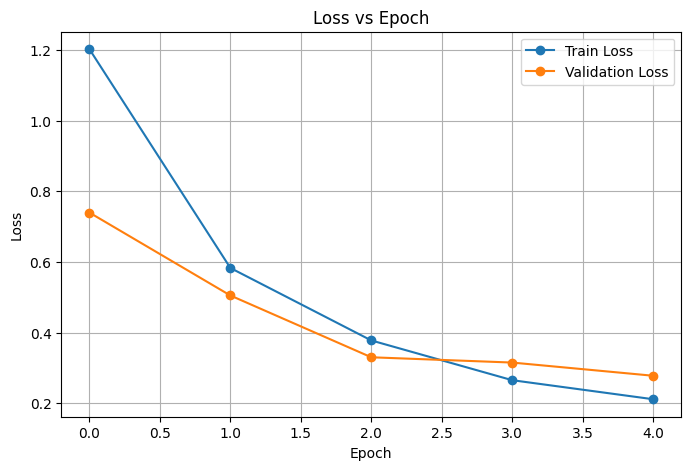

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(train_losses, marker='o', label="Train Loss")
plt.plot(val_losses, marker='o', label="Validation Loss")
plt.title("Loss vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

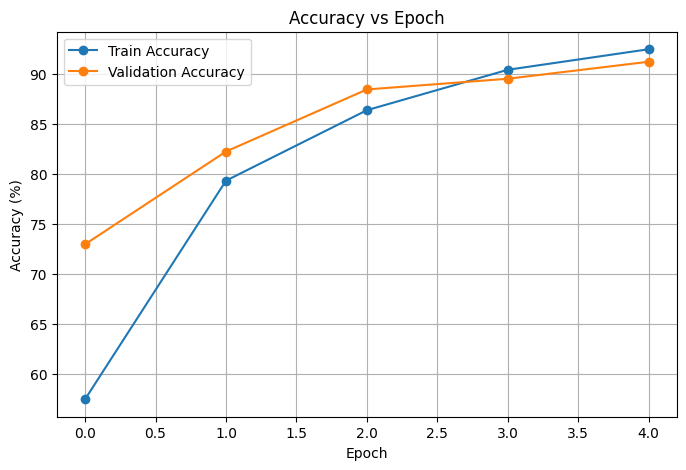

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(train_accuracies, marker='o', label="Train Accuracy")
plt.plot(val_accuracies, marker='o', label="Validation Accuracy")
plt.title("Accuracy vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.grid(True)
plt.show()

#Section 9 - Results Summary

In [ ]:
print("="*45)

print("MambaOut Results")

print("="*45)

print(f"Training Time : {training_time:.2f} sec")
print(f"Training Loss : {train_losses[-1]:.4f}")
print(f"Validation Loss : {val_losses[-1]:.4f}")
print(f"Training Accuracy : {train_accuracies[-1]:.2f}%")
print(f"Validation Accuracy : {val_accuracies[-1]:.2f}%")
print(f"Test Accuracy : {test_accuracy:.2f}%")

print(f"Precision : {precision:.4f}")
print(f"Recall : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"AUC : {auc:.4f}")

MambaOut Results
Training Time : 2301.12 sec
Training Loss : 0.2118
Validation Loss : 0.2782
Training Accuracy : 92.51%
Validation Accuracy : 91.26%
Test Accuracy : 91.04%
Precision : 0.9110
Recall : 0.9104
F1 Score : 0.9096
AUC : 0.9961
